<a href="https://colab.research.google.com/github/ssykes-eth/ETH_273-0003-00L/blob/weekend_2/Autoencoders%20CX/Autoencoders_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Autoencoders: Teaching Machines to Compress and Reconstruct

In-Class Exercise

---

## The Big Picture: What Is an Autoencoder?

Imagine you work at a company that needs to send large reports across a slow network every day. To save bandwidth, you hire two specialists:

- **The Compressor** (Encoder): reads the full report and distills it into a one-page summary — capturing only the essential information.
- **The Reconstructor** (Decoder): takes that one-page summary and re-expands it back into a full (approximate) report.

The better this pair gets at their jobs, the more your company can confidently compress-and-reconstruct with minimal loss of information.

**An autoencoder is exactly this.** It is a neural network trained to compress data into a small "bottleneck" representation (called the **latent space**), and then reconstruct the original data from it. The magic is that no human labels are needed — the network teaches itself.

---

### 🗺️ What We'll Do Today

1. **Explore the dataset** — What does our data look like?
2. **Train a classic autoencoder** — Can it reconstruct images faithfully?
3. 🎯 **Exercise 1** — Explore the reconstruction quality on specific digits
4. **Visualize the latent space** — What does the "summary" look like?
5. 🎯 **Exercise 2** — Interpret what you see in the latent space
6. **Introduce noise** — What happens when the input is corrupted?
7. **Train a denoising autoencoder** — Can we teach it to clean up noisy images?
8. 🎯 **Exercise 3** — Compare both autoencoders head-to-head
9. **Real-world business applications** — Where is this being used right now?
10. ⭐ **BONUS: PCA Denoising** — A classic alternative, for those who want a challenge.


---
##


In [1]:
# @title ⚙️ Setup {display-mode: "form"}

# @markdown The cells below clone the course repo and import all helper functions. You don't need to understand what's in these files — just run them and move on!
# ── Step 1: Clone the course repo ───────────────────────────────────────────
%cd /content
![ ! -d 'coding-exercises' ] && git clone https://github.com/eth-bmai-fs26/coding-exercises.git
%cd coding-exercises
!git checkout week2
%cd "Autoencoders CX"

# ── Step 2: Import helpers ───────────────────────────────────────────────────
from utils import *      # training loops, reconstruct(), plotting helpers, DEVICE
from models import *     # ConvAutoencoder, MNISTClassifier
from data import *       # load_mnist(), add_noise()

setup()                  # confirms device (CPU / GPU)

/content
Cloning into 'coding-exercises'...
remote: Enumerating objects: 631, done.
remote: Counting objects: 100% (30/30), done.
remote: Compressing objects: 100% (22/22), done.
remote: Total 631 (delta 12), reused 18 (delta 8), pack-reused 601 (from 1)
Receiving objects: 100% (631/631), 61.34 MiB | 18.76 MiB/s, done.
Resolving deltas: 100% (323/323), done.
/content/coding-exercises
Branch 'week2' set up to track remote branch 'week2' from 'origin'.
Switched to a new branch 'week2'
/content/coding-exercises/Autoencoders CX
✅ Setup complete. Running on: cuda


---
## 📦 Part 1: Exploring the Dataset

### The Analogy
Before our compressor-reconstructor team can do any work, they need to study the documents they'll be working with. Let's take a look at our data.

We'll be working with the **MNIST dataset** — a famous collection of **70,000 handwritten digit images** (0 through 9), each 28×28 pixels in grayscale. Think of each image as one "document" to be compressed and reconstructed.


In [2]:
X_train, y_train, X_test, y_test = load_mnist()

100%|██████████| 9.91M/9.91M [00:00<00:00, 21.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 501kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.77MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.99MB/s]


Training images : (60000, 28, 28)  → 60,000 images of 28×28 pixels
Test images     : (10000, 28, 28)   → 10,000 images of 28×28 pixels
Digit classes   : [0 1 2 3 4 5 6 7 8 9]


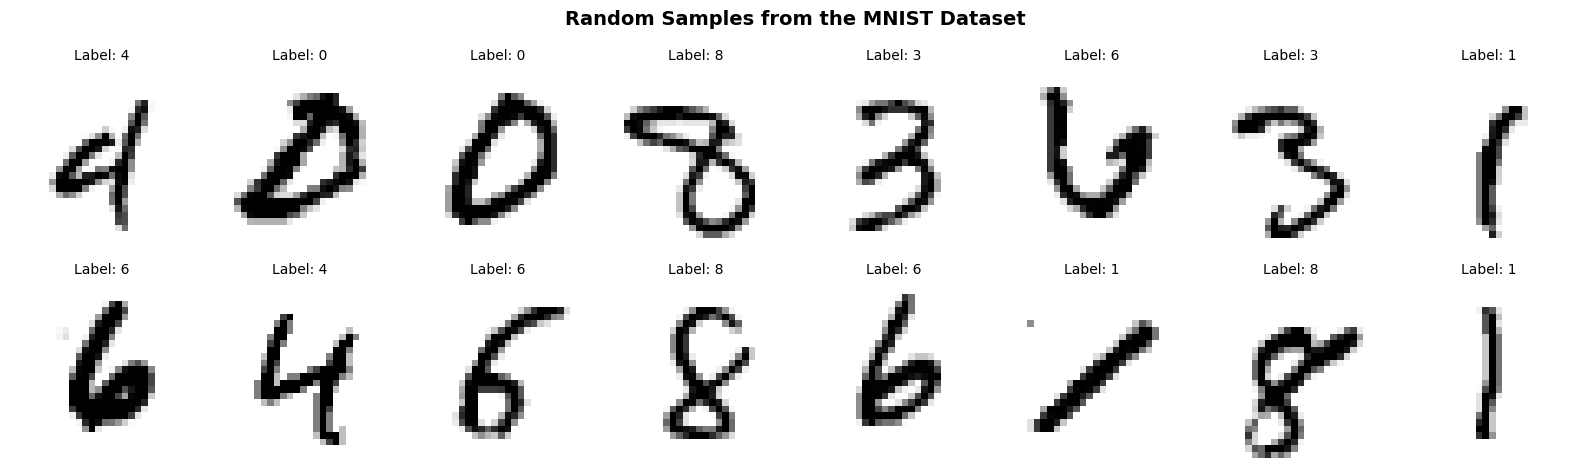

In [3]:
# @title Let's look at some examples {display-mode: "form"}

# @markdown The images below are random samples from our training set. Each one is a handwritten digit with its true label shown above it.

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
fig.suptitle("Random Samples from the MNIST Dataset", fontsize=14, fontweight='bold')

indices = np.random.randint(0, len(X_train), size=16)
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[indices[i]], cmap='gray_r')
    ax.set_title(f"Label: {y_train[indices[i]]}", fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

---
## 🤖 Part 2: Building and Training the Autoencoder

### The Analogy Continued

Now we hire our compression team:
- **The Encoder** squeezes a 28×28 image (784 numbers) down to just **128 numbers** — the "summary".
- **The Decoder** takes those 128 numbers and tries to reconstruct the full 28×28 image.

The network is trained by comparing its output to the original input and adjusting itself to minimize the difference. No labels needed!

> 🧩 **Key concept:** The 128-number summary is called the **latent representation** or **latent space**. It's like a compressed fingerprint of the image.

The architecture is already defined for you in `models.py`. But before you use it, you'll complete the three core methods that make it work.


In [4]:
# @title 🎯 Understanding Check: Which type of learning? { display-mode: "form" }

# @markdown Autoencoders learn a latent representation on their own, without needing any labels. Which type of ML is this?
answer = "Unsupervised learning" # @param ["Supervised learning", "Unsupervised learning", "Reinforcement learning", "Transformers"]

if answer == "Unsupervised learning":
    print("✅ Correct! Autoencoders are Unsupervised. They use the input data as their own 'target' to learn compressed representations.")
elif answer == "Supervised learning":
    print("❌ Not quite. Supervised learning requires explicit labels (like 'Cat' or 'Dog'). Autoencoders work with unlabeled data.")
elif answer == "Reinforcement learning":
    print("❌ Incorrect. Reinforcement learning is based on rewards and penalties. Autoencoders simply try to reconstruct their input.")
elif answer == "Transformers":
    print("❌ That's an architecture, not a learning paradigm! While Transformers can be trained using unsupervised methods, the category here is Unsupervised Learning.")

✅ Correct! Autoencoders are Unsupervised. They use the input data as their own 'target' to learn compressed representations.


---
### 🎯 TODO 1 — Complete `encode()`, `decode()`, and `forward()`

In the cell below, we are declaring the architecture of our autoencoder `class ConvAutoencoder`. Again, an autoencoder is a special type of neural network, so if you remember something from the previous weekend about how to build neural networks in PyTorch, this is gonna feel very familiar!

In `__init__` we have defined the architecture of our autoencoder. Your task is to fill in these methods (functions) inside the class:

**`encode(self, x)`** — The encoder forward pass. Chain these steps in order:
1. Apply `self.encoder_conv` (the convolutional layers)
2. Apply `self.encoder_pool` (the pooling layer)
3. Flatten the result with `.flatten(1)`
4. Apply `self.encoder_fc` and return the result

**`decode(self, z)`** — The decoder forward pass:
1. Apply `self.decoder_fc`
2. Reshape the output to `(-1, 64, 7, 7)` using `.view(...)`
3. Apply `self.decoder_conv` and return the result

**`forward(self, x)`** — The full autoencoder pass (one line):
- Encode `x`, then decode the result

> **Hint:** Look at `__init__` to see what each layer does. The comments show the shape at each step.

Once you've filled them in, run the cell below to create the model.


In [5]:
class ConvAutoencoder(nn.Module):
    """
    Convolutional Autoencoder for MNIST.
    Encoder: (1, 28, 28) → 128-dim latent vector
    Decoder: 128-dim latent vector → (1, 28, 28)
    """
    def __init__(self):
        super().__init__()

        # ── ENCODER ───────────────────────────────────────────────────────────
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),   # → (16, 14, 14)
            nn.BatchNorm2d(16),
            nn.LeakyReLU(0.1),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),  # → (32,  7,  7)
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.1),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),  # → (64,  7,  7)
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.1),
        )
        self.encoder_pool = nn.AdaptiveAvgPool2d((4, 4))             # → (64,  4,  4)
        self.encoder_fc   = nn.Linear(64 * 4 * 4, 128)              # → 128

        # ── DECODER ───────────────────────────────────────────────────────────
        self.decoder_fc   = nn.Sequential(
            nn.Linear(128, 64 * 7 * 7),
            nn.LeakyReLU(0.1),
        )
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=1, padding=1),  # → (32, 7, 7)
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.1),
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1),  # → (16, 14, 14)
            nn.BatchNorm2d(16),
            nn.LeakyReLU(0.1),
            nn.ConvTranspose2d(16,  1, kernel_size=4, stride=2, padding=1),  # → (1, 28, 28)
            nn.Sigmoid(),
        )

    def encode(self, x):
        """
        🎯🎯🎯 TODO 1a 🎯🎯🎯 — Encoder forward pass.
        Chain these steps in order:
          1. Apply self.encoder_conv
          2. Apply self.encoder_pool
          3. Flatten with .flatten(1)
          4. Apply self.encoder_fc and return the result
        """
        x = self.encoder_conv(x)
        x = self.encoder_pool(x)
        x = x.flatten(1)
        x = self.encoder_fc(x)
        return x

    def decode(self, z):
        """
        🎯🎯🎯 TODO 1b 🎯🎯🎯 — Decoder forward pass.
        Chain these steps in order:
          1. Apply self.decoder_fc
          2. Reshape to (-1, 64, 7, 7) using .view(...)
          3. Apply self.decoder_conv and return the result
        """
        x = self.decoder_fc(z)
        x = x.view(-1, 64, 7, 7)
        x = self.decoder_conv(x)
        return x

    def forward(self, x):
        """
        🎯🎯🎯 TODO 1c 🎯🎯🎯 — Full autoencoder pass (one line).
        Encode x, then decode the result.
        """
        return self.decode(self.encode(x))

In [6]:
autoencoder = ConvAutoencoder().to(DEVICE)
total_params = sum(p.numel() for p in autoencoder.parameters())
print(f"✅ Autoencoder created with {total_params:,} trainable parameters")
print(f"   Input  : 1×28×28 = 784 values")
print(f"   Latent : 128 values   (compression ratio: {784/128:.1f}×)")
print(f"   Output : 1×28×28 = 784 values")

✅ Autoencoder created with 586,289 trainable parameters
   Input  : 1×28×28 = 784 values
   Latent : 128 values   (compression ratio: 6.1×)
   Output : 1×28×28 = 784 values


---
### Training the Autoencoder

We implemented a standard neural network training loop in the `train_autoencoder()` function. However, the core gradient update step has been left for you to complete.

---
### 🎯 TODO 2 — Complete the training step

In the `train_autoencoder()` function below you'll find the inner training loop. You'll see three lines marked `# TODO`. Fill them in using the variables already available:

- `model` — the autoencoder  
- `xb` — the input batch  
- `yb` — the target batch (clean images)  
- `loss_fn` — `nn.MSELoss()`  
- `opt` — the Adam optimizer  

The three steps are:
1. Compute the loss: pass `xb` through the model and compare the output to `yb` using the `loss_fn`
2. Backpropagate: call `.backward()` on the loss
3. Update the weights: call `.step()` on the optimizer

> **Note:** `opt.zero_grad()` and gradient clipping are already handled for you — just fill in the three missing lines.

Once done, run the cell below to start training. This will take a few minutes ☕


In [7]:
def train_autoencoder(model, X_train_np, X_input_np=None, epochs=25, batch_size=128, lr=2e-3):
    """
    Train an autoencoder.

    Parameters
    ----------
    model       : ConvAutoencoder instance
    X_train_np  : TARGET images — what we want the output to look like (clean)
    X_input_np  : INPUT  images — what we feed in; defaults to X_train_np.
                  For a denoising autoencoder pass noisy images here.
    epochs      : number of training epochs
    batch_size  : mini-batch size
    lr          : initial learning rate (cosine-annealed)
    """
    if X_input_np is None:
        X_input_np = X_train_np

    X_in  = torch.tensor(X_input_np[:, None, :, :]).to(DEVICE)
    X_tgt = torch.tensor(X_train_np[:, None, :, :]).to(DEVICE)
    loader = DataLoader(TensorDataset(X_in, X_tgt), batch_size=batch_size, shuffle=True)

    opt     = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    sched   = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    loss_fn = nn.MSELoss()
    model.train()

    for epoch in range(1, epochs + 1):
        total = 0
        for xb, yb in loader:
            opt.zero_grad()
            # 🎯🎯🎯 TODO 2 🎯🎯🎯 — Fill in the three training steps:
            #   1. Compute loss: pass xb through model and compare output to yb using loss_fn
            #   2. Backpropagate: call .backward() on the loss
            #   3. Update weights: call .step() on the optimizer

            # 1. Forward pass + compute loss
            out = model(xb)
            loss = loss_fn(out, yb)

            # 2. Backpropagation
            loss.backward()

            # 3. Update weights
            opt.step()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # keep as-is
            total += loss.item() * len(xb)
        sched.step()
        if epoch % 5 == 0 or epoch == 1:
            print(f"  Epoch {epoch:3d}/{epochs} — Loss: {total/len(X_in):.5f}  "
                  f"(lr={sched.get_last_lr()[0]:.5f})")

    print("✅ Training complete!")
    return model

In [8]:
print("Training Classic Autoencoder (clean images → clean images)...")
autoencoder = train_autoencoder(autoencoder, X_train_np=X_train, epochs=25)

Training Classic Autoencoder (clean images → clean images)...
  Epoch   1/25 — Loss: 0.02683  (lr=0.00199)
  Epoch   5/25 — Loss: 0.00346  (lr=0.00181)
  Epoch  10/25 — Loss: 0.00249  (lr=0.00131)
  Epoch  15/25 — Loss: 0.00183  (lr=0.00069)
  Epoch  20/25 — Loss: 0.00132  (lr=0.00019)
  Epoch  25/25 — Loss: 0.00103  (lr=0.00000)
✅ Training complete!


---
### 🔍 How Well Does It Reconstruct?

Before we can visualise reconstructions, we need a function to run images through the model at inference time. This is slightly different from training — we need to tell PyTorch we're not computing gradients.

---
### 🎯 TODO 3 — Complete `reconstruct()`

Below you'll find the `reconstruct()` function. Fill in the body:

1. Set the model to evaluation mode with `model.eval()`
2. Wrap your code in a `torch.no_grad()` context manager (this disables gradient tracking)
3. Inside it:
   - Convert `X_np` to a torch tensor, add a channel dimension (`[:, None, :, :]`), move to `DEVICE`
   - Pass it through `model(...)`
   - Store the result in `out`
4. Return `out.cpu().numpy()[:, 0, :, :]` (moves back to CPU and removes the channel dim)

> **Why `model.eval()`?** It disables dropout and sets BatchNorm to use running statistics — important for consistent inference results.

Once done, run the cell below.


In [ ]:
# @title Need an extra hint? { display-mode: "form" }
# @markdown Click on "show code" to have some help with converting `X_np` to a tensor and adding the extra dimension

# HINT
X_np_as_tensor = torch.tensor(X_np[:, None, :, :])

In [9]:
def reconstruct(model, X_np):
    """
    🎯🎯🎯 TODO 3 🎯🎯🎯 — Implement inference through the autoencoder.

    Steps:
      1. Set model to eval mode with model.eval()
      2. Inside a torch.no_grad() block:
           - Convert X_np to a tensor, add channel dim ([:, None, :, :]), move to DEVICE
           - Pass through model and store in
      3. Return out.cpu().numpy()[:, 0, :, :]

    Parameters
    ----------
    model : trained ConvAutoencoder
    X_np  : images, shape (N, 28, 28)

    Returns
    -------
    Reconstructed images as float32 numpy array, shape (N, 28, 28).
    """
    # YOUR CODE HERE (replace line below)
    model.eval()

    with torch.no_grad():
        x = torch.tensor(X_np[:, None, :, :]).to(DEVICE)
        out = model(x)

    return out.cpu().numpy()[:, 0, :, :]

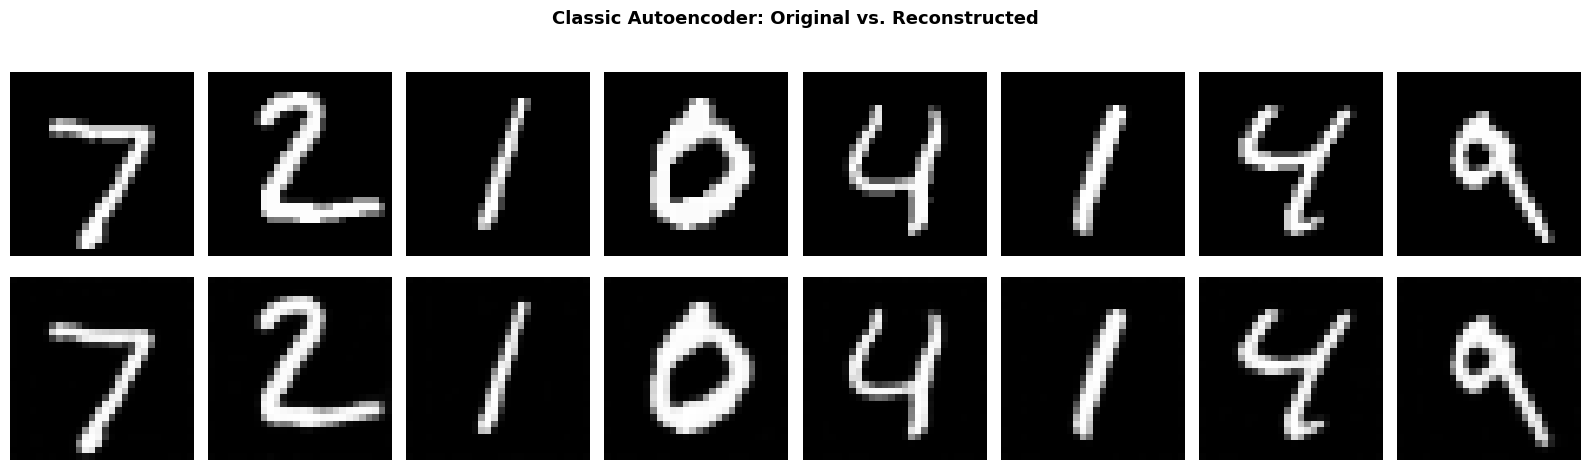

In [10]:
recon_classic = reconstruct(autoencoder, X_test)
plot_original_vs_reconstructed(X_test, recon_classic,
                                title="Classic Autoencoder: Original vs. Reconstructed")

Should look pretty good! But how good?

---
### 📊 Measuring Quality with a Digit Classifier

Looking at images is subjective. To measure quality more rigorously, we train a simple digit classifier on *clean* images, and then ask it to classify the *reconstructed* images. If the reconstructions are good, the classifier should still recognise the digits correctly.

> **Think of it this way:** after our compressor-reconstructor team processes a document, we ask a human reader to see if they can still understand the content. Their comprehension rate is our quality metric.


Training digit classifier on clean images (this takes ~1 min)...

Evaluating on RECONSTRUCTED test images:
  Accuracy: 98.99%


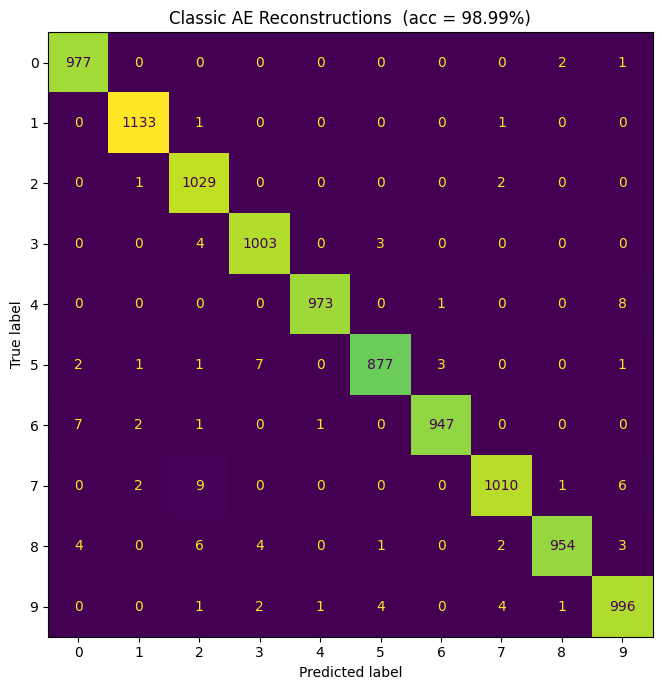

In [11]:
#@title {display-mode: "form"}
print("Training digit classifier on clean images (this takes ~1 min)...")
classifier = train_classifier(MNISTClassifier, X_train, y_train)

print("\nEvaluating on RECONSTRUCTED test images:")
acc_classic = evaluate_and_plot_confusion(classifier, recon_classic, y_test,
                                           title="Classic AE Reconstructions")

---
## Exploring Reconstruction Quality Per Digit

### Context

The confusion matrix above gives you an overall accuracy, but it treats all 10 digits equally. In practice, some digits might be reconstructed much better than others, and knowing *which ones* is valuable.

**Why does this matter in business?**
Imagine you're using an autoencoder to compress medical scan images before transmitting them over the network. If the autoencoder reconstructs certain types of scans poorly, that's a critical issue, even if the average quality is high.

In this exercise, you'll dig into the reconstruction quality *per digit class* to identify where the autoencoder struggles most.

---


Average reconstruction MSE per digit:
  Digit 0: 0.00126
  Digit 1: 0.00041
  Digit 2: 0.00124
  Digit 3: 0.00111
  Digit 4: 0.00096
  Digit 5: 0.00114
  Digit 6: 0.00120
  Digit 7: 0.00086
  Digit 8: 0.00142
  Digit 9: 0.00097


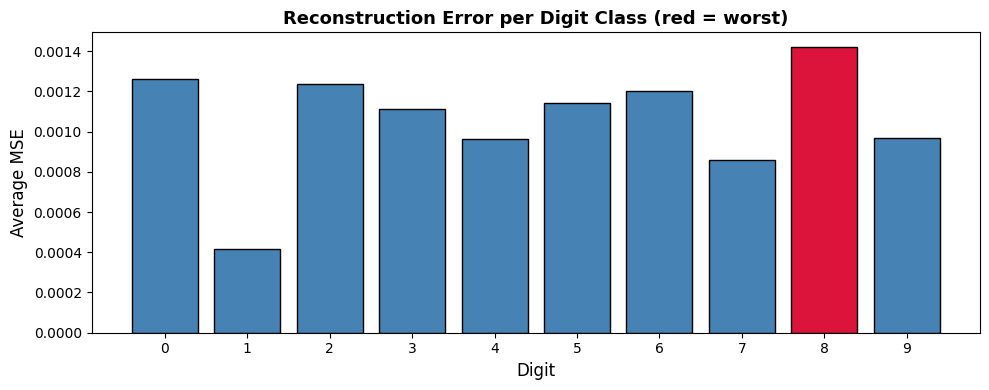


Worst reconstructed digit: 8


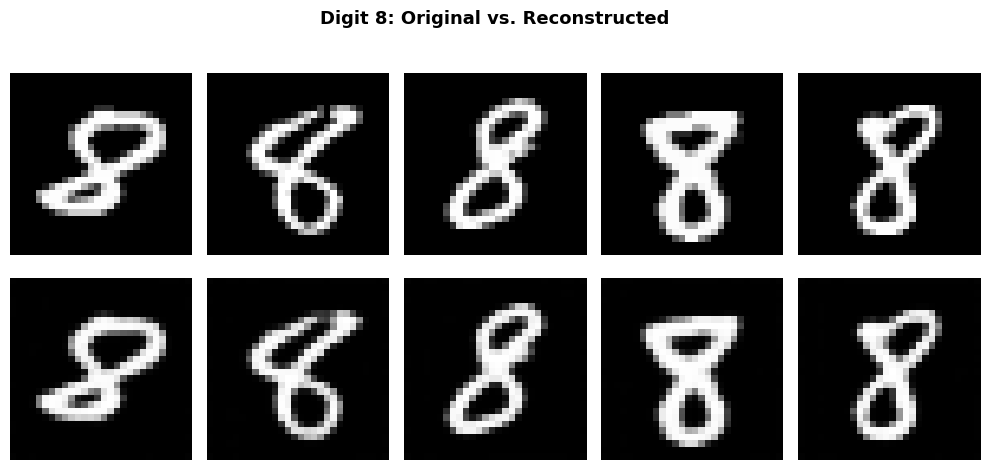

In [12]:
# @title Let's look at some reconstruction quality statistics per digit { display-mode: "form" }
digit_mse = {}
for d in range(10):
    mask  = (y_test == d)
    orig  = X_test[mask]
    recon = recon_classic[mask]
    digit_mse[d] = np.mean((orig - recon)**2)

print("Average reconstruction MSE per digit:")
for d, mse in digit_mse.items():
    print(f"  Digit {d}: {mse:.5f}")

# Task 2: Bar chart
fig, ax = plt.subplots(figsize=(10, 4))
colors = ['crimson' if v == max(digit_mse.values()) else 'steelblue' for v in digit_mse.values()]
ax.bar(list(digit_mse.keys()), list(digit_mse.values()), color=colors, edgecolor='black')
ax.set_xlabel("Digit", fontsize=12)
ax.set_ylabel("Average MSE", fontsize=12)
ax.set_title("Reconstruction Error per Digit Class (red = worst)", fontsize=13, fontweight='bold')
ax.set_xticks(range(10))
plt.tight_layout(); plt.show()

# Task 3: Worst digit
worst_digit = max(digit_mse, key=digit_mse.get)
print(f"\nWorst reconstructed digit: {worst_digit}")

mask_worst  = (y_test == worst_digit)
orig_worst  = X_test[mask_worst][:5]
recon_worst = recon_classic[mask_worst][:5]
plot_original_vs_reconstructed(orig_worst, recon_worst, n=5,
                                title=f"Digit {worst_digit}: Original vs. Reconstructed")

Average reconstruction MSE per digit:
  Digit 0: 0.00126
  Digit 1: 0.00041
  Digit 2: 0.00124
  Digit 3: 0.00111
  Digit 4: 0.00096
  Digit 5: 0.00114
  Digit 6: 0.00120
  Digit 7: 0.00086
  Digit 8: 0.00142
  Digit 9: 0.00097


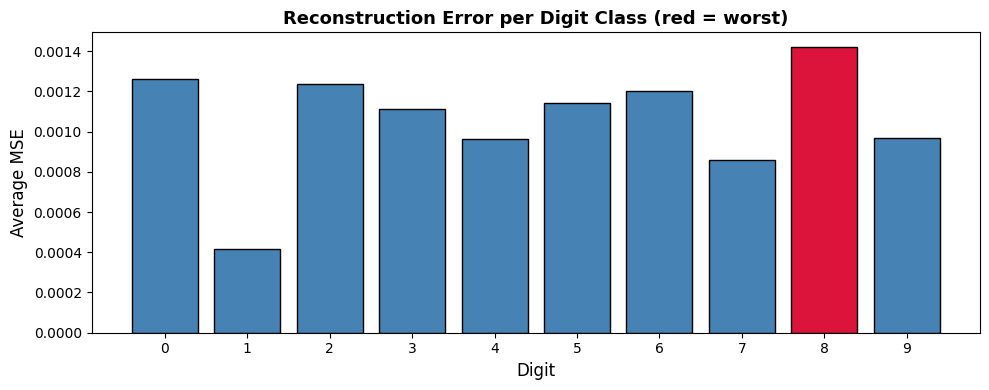


Worst reconstructed digit: 8


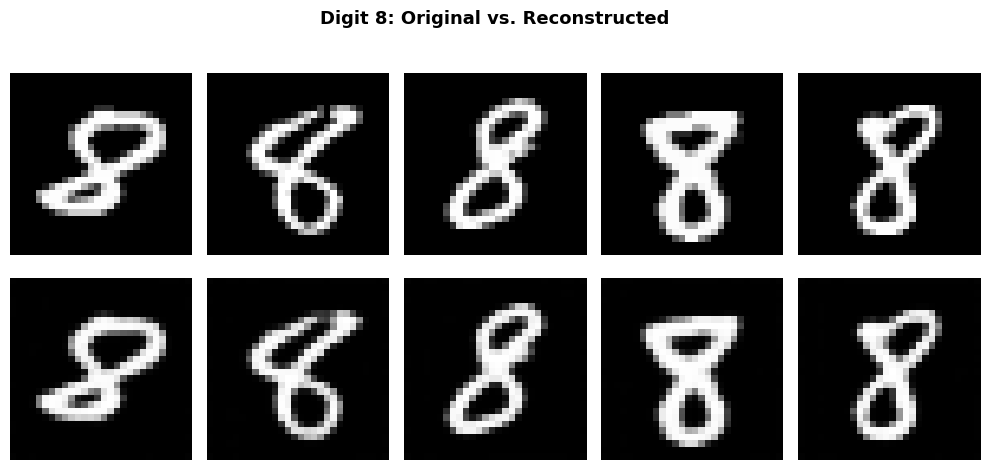

In [13]:
digit_mse, worst_digit = plot_per_digit_mse(recon_classic, X_test, y_test)

### 💬 Debrief

Think about what you found:
- Which digit has the highest reconstruction error? Does this make intuitive sense given what that digit looks like? Is the error much higher?
- The digits 3, 5, and 8 often have the highest errors — they share curved strokes that are hard to distinguish in a compressed representation.
- **Business takeaway:** Average metrics hide per-class weaknesses. Always investigate disaggregated performance before deploying a model.


---
## 🌐 Part 3: Visualizing the Latent Space

### What Does the "Summary" Look Like?

Remember our 128-number bottleneck? Each image gets mapped to a point in this 128-dimensional space. We can't visualise 128 dimensions, but we can use **PCA** to project it down to 2D.

**What should we expect?** If the autoencoder learned meaningful features, images of the same digit should cluster together. The "1" images should be near each other, and far from "8" images — and this should show in the compressed representation.


2D PCA explains 16.8% of latent variance


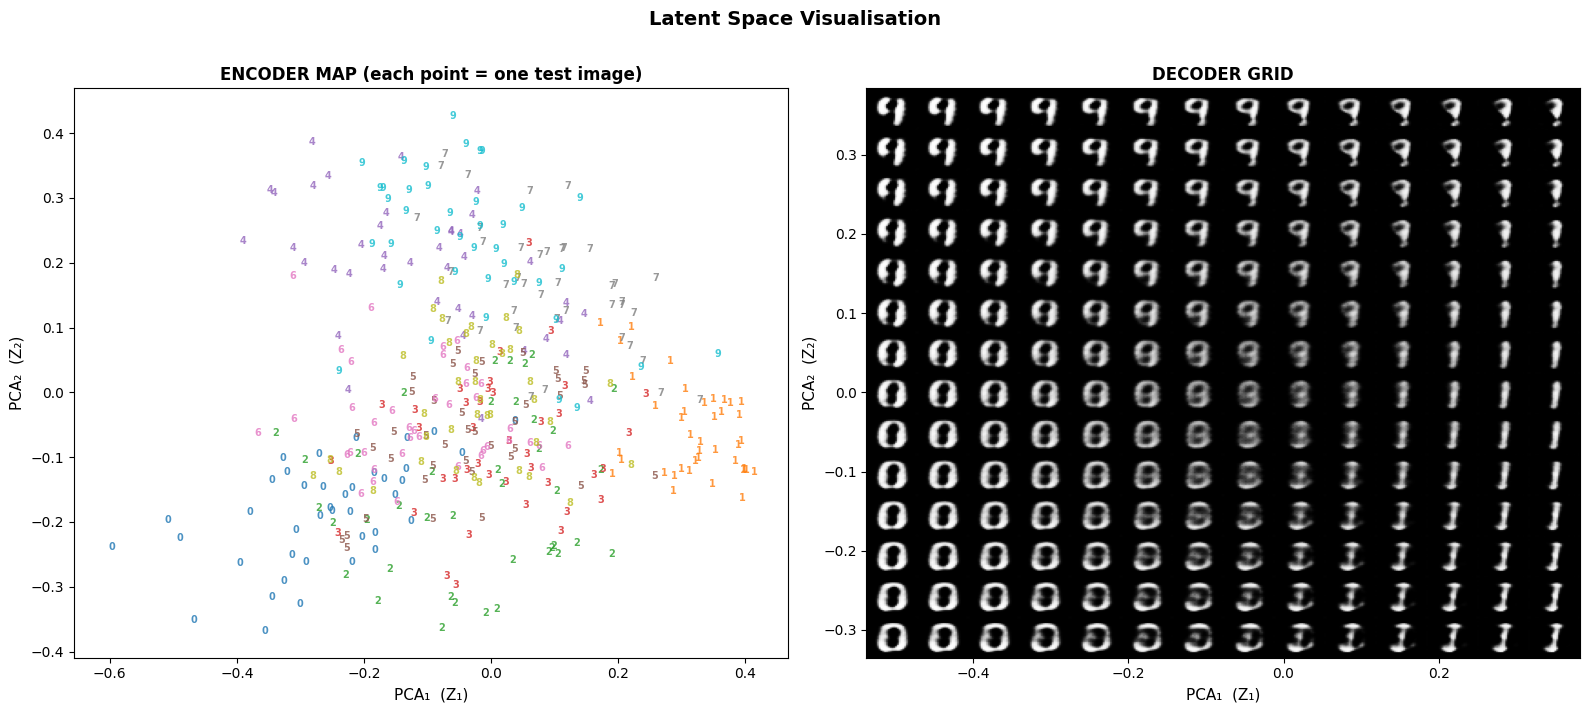

In [14]:
# @title Latent space visualization {display-mode: "form"}

from sklearn.decomposition import PCA

# ── Step 1: Extract latent vectors for a subset of test images ───────────────
N_VIZ = 2000
autoencoder.eval()
with torch.no_grad():
    latent_all = autoencoder.encode(
        torch.tensor(X_test[:N_VIZ, None, :, :]).to(DEVICE)
    ).cpu().numpy()

labels_viz = y_test[:N_VIZ]

# Project to 2D with PCA
pca_viz  = PCA(n_components=2)
lat_2d   = pca_viz.fit_transform(latent_all)
var_exp  = pca_viz.explained_variance_ratio_.sum()
print(f"2D PCA explains {var_exp:.1%} of latent variance")

# ── Step 2: Build decoder grid ────────────────────────────────────────────────
GRID = 14
x_range = np.linspace(lat_2d[:, 0].min() * 0.9, lat_2d[:, 0].max() * 0.9, GRID)
y_range = np.linspace(lat_2d[:, 1].max() * 0.9, lat_2d[:, 1].min() * 0.9, GRID)

grid_points_2d = np.array([[x, y] for y in y_range for x in x_range], dtype="float32")
grid_latent = pca_viz.inverse_transform(grid_points_2d)
autoencoder.eval()
with torch.no_grad():
    grid_images = autoencoder.decode(
        torch.tensor(grid_latent).to(DEVICE)
    ).cpu().numpy()[:, 0, :, :]

canvas_h = GRID * 28
canvas_w = GRID * 28
decoder_canvas = np.zeros((canvas_h, canvas_w))
for idx, img in enumerate(grid_images):
    r, c = divmod(idx, GRID)
    decoder_canvas[r*28:(r+1)*28, c*28:(c+1)*28] = img

# ── Step 3: Side-by-side plot ────────────────────────────────────────────────
COLORS = plt.cm.tab10(np.linspace(0, 1, 10))
fig, (ax_enc, ax_dec) = plt.subplots(1, 2, figsize=(16, 7))

for d in range(10):
    mask = labels_viz == d
    for x, y in zip(lat_2d[mask, 0][:40], lat_2d[mask, 1][:40]):
        ax_enc.text(x, y, str(d), fontsize=7, color=COLORS[d],
                    ha='center', va='center', fontweight='bold', alpha=0.8)
# Automatically scale the limits based on the data
ax_enc.set_xlim(lat_2d[:, 0].min() * 1.1, lat_2d[:, 0].max() * 1.1)
ax_enc.set_ylim(lat_2d[:, 1].min() * 1.1, lat_2d[:, 1].max() * 1.1)
ax_enc.set_xlabel("PCA₁  (Z₁)", fontsize=11); ax_enc.set_ylabel("PCA₂  (Z₂)", fontsize=11)
ax_enc.set_title("ENCODER MAP (each point = one test image)", fontsize=12, fontweight='bold')

ax_dec.imshow(decoder_canvas, cmap='gray', origin='upper',
              extent=[x_range[0], x_range[-1], y_range[-1], y_range[0]], aspect='auto')
ax_dec.set_xlabel("PCA₁  (Z₁)", fontsize=11); ax_dec.set_ylabel("PCA₂  (Z₂)", fontsize=11)
ax_dec.set_title("DECODER GRID", fontsize=12, fontweight='bold')

plt.suptitle("Latent Space Visualisation", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

2D PCA explains 16.8% of latent variance


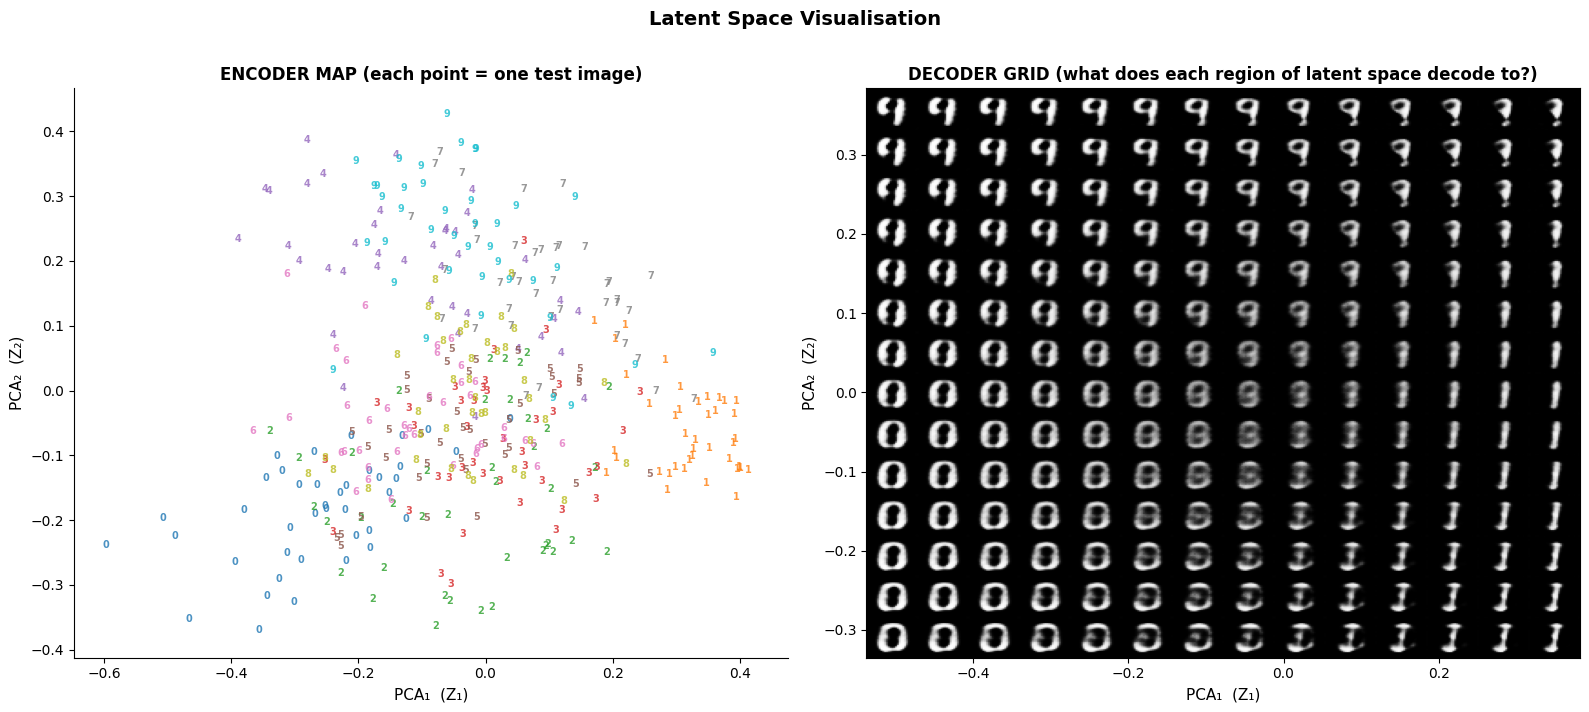

In [15]:
lat_2d, labels_viz, pca_viz = visualise_latent_space(autoencoder, X_test, y_test)

### 💡 How to Read This Plot

**Left — Encoder Map:** Each digit label represents one test image, positioned according to where the autoencoder *compressed* it in latent space. Same digits cluster together. Digits that look alike (3 & 8, 4 & 9) sit closer together.

**Right — Decoder Grid:** We systematically sweep across the 2D latent space and *decode* each point back to an image. The grid shows what the autoencoder would generate at each location. Notice how digits transition smoothly — there are no sharp edges, just gradual morphing.


---
## Probing the Latent Space

### Context

The 2D plot above gives you a *bird's eye view* of the latent space. In this exercise, you'll find which digit classes are *most confused* with each other in the compressed representation.

**Why does this matter?**
In anomaly detection (fraud, network intrusion, quality control), the latent space determines which inputs get flagged as "unusual". Understanding where the boundaries are is critical.

---


Most confused digit pair: 5 and 8 (centroid distance: 0.038)


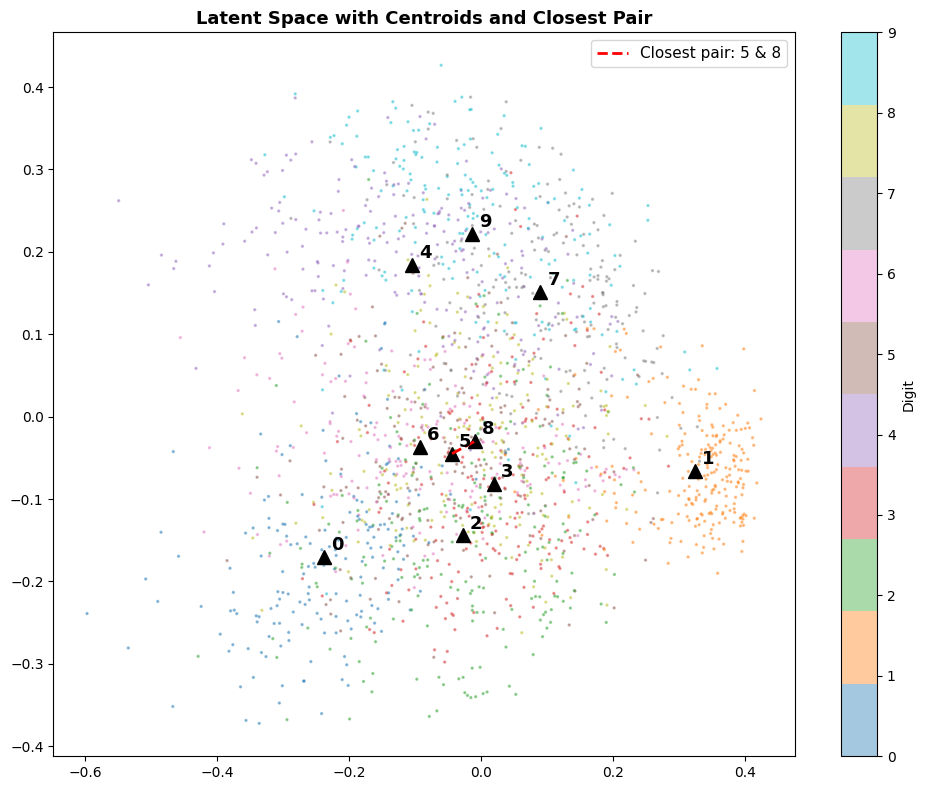

In [16]:
# @title Probing the Latent Space {display-mode: "form"}

# Re-extract latent vectors and perform PCA for this cell's context
N_VIZ = 2000   # use 2000 points to keep the plot readable
autoencoder.eval()
with torch.no_grad():
    latent_all = autoencoder.encode(
        torch.tensor(X_test[:N_VIZ, None, :, :]).to(DEVICE)
    ).cpu().numpy()

labels_viz = y_test[:N_VIZ]

pca_viz  = PCA(n_components=2)
lat_2d   = pca_viz.fit_transform(latent_all)

# Task 1: Centroids
centroids = {d: lat_2d[labels_viz == d].mean(axis=0) for d in range(10)}

# Tasks 2 & 3: Closest pair
min_dist = float('inf')
closest_pair = (None, None)
for i in range(10):
    for j in range(i+1, 10):
        dist = np.linalg.norm(centroids[i] - centroids[j])
        if dist < min_dist:
            min_dist = dist
            closest_pair = (i, j)

print(f"Most confused digit pair: {closest_pair[0]} and {closest_pair[1]} "
      f"(centroid distance: {min_dist:.3f})")

# Task 4: Plot with centroids and closest pair
fig, ax = plt.subplots(figsize=(10, 8))
sc = ax.scatter(lat_2d[:, 0], lat_2d[:, 1], c=labels_viz, cmap='tab10', s=2, alpha=0.4)
plt.colorbar(sc, ax=ax, ticks=range(10)).set_label('Digit', fontsize=10)

for d, c in centroids.items():
    ax.plot(*c, 'k^', markersize=10)
    ax.annotate(str(d), c, fontsize=13, fontweight='bold',
                xytext=(5, 5), textcoords='offset points')

a, b = closest_pair
ax.plot([centroids[a][0], centroids[b][0]],
        [centroids[a][1], centroids[b][1]],
        'r--', linewidth=2, label=f"Closest pair: {a} & {b}")
ax.legend(fontsize=11)
ax.set_title("Latent Space with Centroids and Closest Pair", fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

Most confused digit pair: 5 and 8 (centroid distance: 0.038)


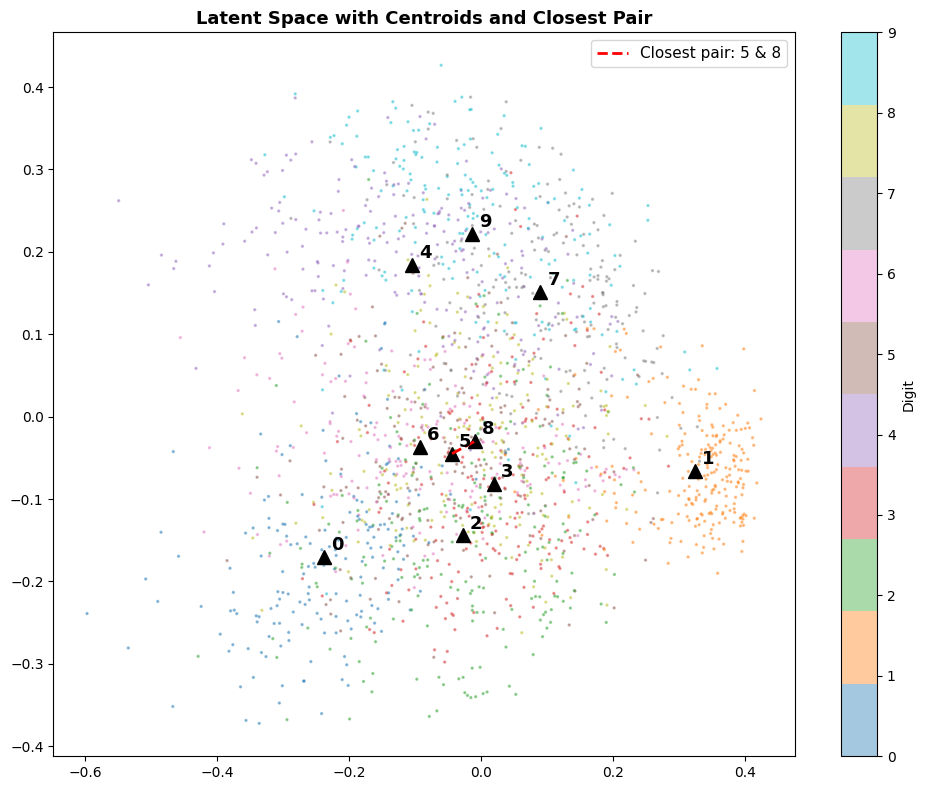

In [17]:
centroids, closest_pair = probe_latent_space(lat_2d, labels_viz)

### 💬 Debrief

The closest pair in the latent space often turns out to be 5 & 8 — digits that share structural features (curves, vertical strokes). This reflects what the autoencoder *actually learned* about the data structure.

- **Connection to Exercise 1:** The digit pairs most confused in the latent space are often also the ones with highest reconstruction error.
- **Business takeaway:** Before deploying an autoencoder-based anomaly detector, map your latent space. Understand which "normal" patterns sit close together — those boundaries are where your false alarm rate will be highest.


---
## 🌧️ Part 4: What Happens with Noisy Input?

In practice, data is rarely clean. Medical scans have artifacts. Financial records have entry errors. Sensor data has interference. What happens when we feed our autoencoder corrupted input?

---
### 🎯 TODO 4 — Generate noisy images using `add_noise()`

Open **`data.py`** and find the `add_noise()` function. Fill in the body:

1. Generate Gaussian noise with the same shape as `X` using `rng.standard_normal(X.shape)`
2. Add `noise_factor * noise` to `X`
3. Clip the result to `[0, 1]` with `np.clip(..., 0, 1)` and return as `float32`

Once done, run the cell below.


In [ ]:
def add_noise(X, noise_factor=0.3, seed=None):
    """
    Adds Gaussian noise to images and clips the result to [0, 1].

    Parameters
    ----------
    X            : numpy array of shape (N, 28, 28)
    noise_factor : standard deviation of the noise
    seed         : optional random seed for reproducibility

    Returns
    -------
    Noisy images as float32 array, same shape as X.
    """
    rng = np.random.default_rng(seed)
    unscaled_noise = rng.standard_normal(X.shape).astype("float32")
    # 🎯🎯🎯 TODO 4 🎯🎯🎯 — Generate noisy images:
    #   1. Multiply by the noise by noise_factor and add to X
    #   2. Clip the result to [0, 1] with np.clip(..., 0, 1) and return as float32
    # YOUR CODE HERE (replace the line below)
    raise NotImplementedError

In [ ]:
# @title Let's visualize some sample clean images and the version with added noise {display-mode: "form"}

X_train_noisy = add_noise(X_train, noise_factor=0.3, seed=42)
X_test_noisy  = add_noise(X_test,  noise_factor=0.3, seed=42)

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
fig.suptitle("Clean vs. Noisy Images", fontsize=13, fontweight='bold')
for i in range(8):
    axes[0, i].imshow(X_test[i],       cmap='gray'); axes[0, i].axis('off')
    axes[1, i].imshow(X_test_noisy[i], cmap='gray'); axes[1, i].axis('off')
axes[0, 0].set_ylabel("Clean",  fontsize=11)
axes[1, 0].set_ylabel("Noisy", fontsize=11)
plt.tight_layout(); plt.show()

### Feeding Noisy Images to the Classic Autoencoder

The classic autoencoder was trained only on clean images. What will it do with noisy input?


In [ ]:
# @title How does our classic Autoencoder do on noisy input? {display-mode: "form"}

recon_noisy_classic = reconstruct(autoencoder, X_test_noisy)

fig, axes = plt.subplots(3, 8, figsize=(16, 7))
fig.suptitle("Classic AE on Noisy Input", fontsize=13, fontweight='bold')
for i in range(8):
    axes[0, i].imshow(X_test_noisy[i],       cmap='gray'); axes[0, i].axis('off')
    axes[1, i].imshow(recon_noisy_classic[i], cmap='gray'); axes[1, i].axis('off')
    axes[2, i].imshow(X_test[i],              cmap='gray'); axes[2, i].axis('off')
axes[0, 0].set_ylabel("Noisy Input",  fontsize=10)
axes[1, 0].set_ylabel("AE Output",    fontsize=10)
axes[2, 0].set_ylabel("Ground Truth", fontsize=10)
plt.tight_layout(); plt.show()

print("Classifier accuracy on classic AE outputs (noisy input):")
acc_noisy_classic = evaluate_and_plot_confusion(classifier, recon_noisy_classic, y_test,
                                                 title="Classic AE on Noisy Input")

### 📉 As Expected — It Struggles

The classic autoencoder was trained to compress-and-reconstruct clean images. When faced with noisy input, the noise gets "baked in" to the reconstruction.

**The fix:** Train the autoencoder *specifically* to remove noise — feed it noisy images as input, and ask it to output clean images. This is called a **Denoising Autoencoder**.


---
## 🧹 Part 5: The Denoising Autoencoder

### A Smarter Compression Team

Instead of clean → clean, we train on **noisy → clean**. Same architecture, different training objective: *learn to remove the noise*.

> **Business Analogy:** This is like training a document processing team specifically on garbled faxes — so they learn to infer the intent even when the input is messy.

---
### 🎯 TODO 5 — Train the Denoising Autoencoder

`train_autoencoder()` accepts two image arrays:
- `X_train_np` — the **target** (what the output should look like)
- `X_input_np` — the **input** (what we feed in)

For the classic AE we passed clean images to both. For the denoising AE, pass:
- `X_train_np = X_train` (clean targets)
- `X_input_np = X_train_noisy` (noisy inputs)

Fill in the call below.


In [ ]:
denoising_ae = ConvAutoencoder().to(DEVICE)
print("Training Denoising Autoencoder (input=noisy, target=clean)...")

denoising_ae = train_autoencoder(
    model=denoising_ae,
    X_train_np=????,       # 🎯🎯🎯 TODO 🎯🎯🎯 fill this line
    X_input_np=????,       # 🎯🎯🎯 TODO 🎯🎯🎯 fill this line with noisy images
    epochs=20
)

In [ ]:
# @title How does our _denoising_ Autoencoder do on noisy input? {display-mode: "form"}

recon_denoised = reconstruct(denoising_ae, X_test_noisy)

fig, axes = plt.subplots(3, 8, figsize=(16, 7))
fig.suptitle("Denoising AE: Noisy → Denoised → Original", fontsize=13, fontweight='bold')
for i in range(8):
    axes[0, i].imshow(X_test_noisy[i],  cmap='gray'); axes[0, i].axis('off')
    axes[1, i].imshow(recon_denoised[i], cmap='gray'); axes[1, i].axis('off')
    axes[2, i].imshow(X_test[i],         cmap='gray'); axes[2, i].axis('off')
axes[0, 0].set_ylabel("Noisy Input",  fontsize=10)
axes[1, 0].set_ylabel("Denoised",     fontsize=10)
axes[2, 0].set_ylabel("Ground Truth", fontsize=10)
plt.tight_layout(); plt.show()

print("Classifier accuracy on denoising AE outputs:")
acc_denoised = evaluate_and_plot_confusion(classifier, recon_denoised, y_test,
                                            title="Denoising Autoencoder Output")

---
## Head-to-Head Comparison

### Context

You've now trained two autoencoders:
1. **Classic AE** — trained on clean images, tested on noisy input (struggles)
2. **Denoising AE** — trained on noisy→clean pairs (handles noise well)

This exercise brings them together for a structured comparison. In a business setting, this is analogous to a **model evaluation report** before deciding which system to deploy.

---


In [ ]:
# @title Head-to-head comparison: classic vs denoising AE {display-mode: "form"}


mse_classic  = {d: np.mean((recon_noisy_classic[y_test == d] - X_test[y_test == d])**2) for d in range(10)}
mse_denoised = {d: np.mean((recon_denoised[y_test == d]      - X_test[y_test == d])**2) for d in range(10)}

#Grouped bar chart
x = np.arange(10)
width = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, [mse_classic[d]  for d in range(10)], width, label='Classic AE',   color='tomato')
ax.bar(x + width/2, [mse_denoised[d] for d in range(10)], width, label='Denoising AE', color='seagreen')
ax.set_xlabel("Digit"); ax.set_ylabel("Avg MSE (lower = better)")
ax.set_title("Per-Digit Reconstruction Error: Classic vs. Denoising AE", fontsize=13, fontweight='bold')
ax.set_xticks(x); ax.legend(); plt.tight_layout(); plt.show()

#Summary table
print(f"{'Digit':>6} | {'Classic MSE':>12} | {'Denoising MSE':>14} | Winner")
print("-" * 52)
for d in range(10):
    winner = 'Denoising AE' if mse_denoised[d] < mse_classic[d] else 'Classic AE'
    print(f"{d:>6} | {mse_classic[d]:>12.5f} | {mse_denoised[d]:>14.5f} | {winner}")

#Largest gap
gaps = {d: mse_classic[d] - mse_denoised[d] for d in range(10)}
biggest_gap_digit = max(gaps, key=gaps.get)
print(f"\nLargest improvement on digit: {biggest_gap_digit} (gap = {gaps[biggest_gap_digit]:.5f})")

mask = (y_test == biggest_gap_digit)
fig, axes = plt.subplots(4, 5, figsize=(12, 10))
fig.suptitle(f"Digit {biggest_gap_digit}: Detailed Comparison", fontsize=13, fontweight='bold')
for i in range(5):
    axes[0, i].imshow(X_test_noisy[mask][i],       cmap='gray'); axes[0, i].axis('off')
    axes[1, i].imshow(recon_noisy_classic[mask][i], cmap='gray'); axes[1, i].axis('off')
    axes[2, i].imshow(recon_denoised[mask][i],      cmap='gray'); axes[2, i].axis('off')
    axes[3, i].imshow(X_test[mask][i],              cmap='gray'); axes[3, i].axis('off')

    # Logic to handle axis visibility
    for row in range(4):
        if i == 0:
            # For the first column: Keep the axis for labels, but hide ticks
            axes[row, i].set_xticks([])
            axes[row, i].set_yticks([])
        else:
            # For all other columns: Complete hide
            axes[row, i].axis('off')

axes[0, 0].set_ylabel("Noisy Input",  fontsize=9)
axes[1, 0].set_ylabel("Classic AE",   fontsize=9)
axes[2, 0].set_ylabel("Denoising AE", fontsize=9)
axes[3, 0].set_ylabel("Ground Truth", fontsize=9)
plt.tight_layout(); plt.show()

In [ ]:
# @title Head-to-head comparison: classic vs denoising AE {display-mode: "form"}

compare_models_head_to_head(recon_noisy_classic, recon_denoised, X_test, X_test_noisy, y_test)


### 💬 Debrief

You've just produced a model evaluation report — the kind of analysis that would precede a real deployment decision.

Key observations:
- The denoising AE wins on virtually every digit, usually by a large margin.
- The *relative* improvement varies across digits. Digits with more complex shapes benefit more from denoising.
- **Business takeaway:** Before choosing between models, understand *where* each one fails — not just the overall score.


---
## 🏢 Part 6: Where Are Autoencoders Used in Business Today?

Autoencoders aren't just an academic exercise. Here are real-world scenarios where the same principles you just explored are being applied at scale:

---

### 1. 🏦 Fraud Detection in Banking

**The challenge:** Banks process millions of transactions per day. Most are normal. A handful are fraudulent — but what does "normal" even look like?

**How autoencoders help:** An autoencoder is trained on *normal* transactions only. It learns to compress and reconstruct normal patterns very well. When a fraudulent transaction arrives — with unusual patterns the model has never seen — the reconstruction error spikes. That spike is the fraud signal. Companies like PayPal and Visa use anomaly detection systems built on this principle.

---

### 2. 🏥 Medical Image Enhancement

**The challenge:** MRI and CT scans are expensive to acquire at high quality. Low-dose or fast scans are cheaper but noisier.

**How autoencoders help:** A denoising autoencoder — just like the one you trained — is trained on pairs of (low-quality, high-quality) medical images. It learns to clean up noisy scans, enabling faster, cheaper imaging without sacrificing diagnostic quality.

---

### 3. 🛒 Recommender Systems & Personalization

**The challenge:** A streaming service has millions of users and thousands of items. Storing and processing every user's full preference history is costly.

**How autoencoders help:** Autoencoders learn a compact latent representation of each user's behaviour. Users close together in latent space have similar tastes — powering real-time recommendations.

---

### 4. 🏭 Predictive Maintenance in Manufacturing

**The challenge:** Industrial machines generate thousands of sensor readings per second. Failures are rare but costly.

**How autoencoders help:** An autoencoder is trained on normal operating data. Any deviation — a failing bearing, a temperature anomaly — shows up as elevated reconstruction error. Maintenance teams can intervene before a breakdown occurs.

---

> **The common thread:** In all these cases, the autoencoder learns what "normal" looks like — and flags anything that doesn't fit. This is extraordinarily useful where labelled data is scarce or expensive.


---
---

## ⭐ BONUS: PCA Denoising — A Classic Alternative

> **This section is optional.** If you've made it here and want a deeper challenge, read on. Otherwise, feel free to stop — you've already covered all the core concepts!

---

### Background: PCA as a Compressor

Before deep learning, **Principal Component Analysis (PCA)** was the workhorse for dimensionality reduction. Like an autoencoder, PCA compresses data into a lower-dimensional representation — but it does so *linearly*.

| | PCA | Autoencoder |
|---|---|---|
| Compression type | Linear only | Non-linear |
| Training cost | Instant (math formula) | Slow (gradient descent) |
| Flexibility | Limited | Very flexible |
| Interpretability | High | Lower |

PCA can be used for denoising: project noisy images into a lower-dimensional subspace (capturing the signal), then project back. The noise, being random, doesn't align well with the principal components and gets attenuated.

---

### 🧑‍💻 Your Task

Implement PCA denoising and compare it against the autoencoder. Fill in the `???` gaps below.


In [ ]:
from sklearn.decomposition import PCA

# Task 1: Flatten images from (N, 28, 28) to (N, 784)
X_train_noisy_flat = X_train_noisy.reshape(len(X_train_noisy), -1)
X_test_noisy_flat  = X_test_noisy.reshape(len(X_test_noisy),   -1)

# Task 2: Fit PCA on the noisy training images
n_components = 64
pca = PCA(n_components=n_components)
pca.fit(???)   # 🎯🎯🎯 TODO 🎯🎯🎯 - fit on flattened noisy training images

# Task 3: Project noisy test images into PCA space and back
recon_pca_flat = pca.inverse_transform(pca.transform(???))   # 🎯🎯🎯 TODO 🎯🎯🎯 - transform then inverse_transform test images

# Task 4: Clip to [0, 1] and reshape back to (N, 28, 28)
# 🎯🎯🎯 TODO 🎯🎯🎯 - What are you clipping?
recon_pca = np.clip(???, 0, 1).reshape(-1, 28, 28).astype("float32")

# Task 5: Visualise
plot_original_vs_reconstructed(X_test_noisy, recon_pca,
    title=f"PCA Denoising (n={n_components}): Noisy vs. Denoised")

# Task 6: Evaluate with the classifier
print("Classifier accuracy on PCA-denoised images:")
acc_pca = evaluate_and_plot_confusion(classifier, recon_pca, y_test,
                                       title=f"PCA Denoising (n={n_components})")

# Final comparison
print("\n── Final Accuracy Summary ───────────────────────────────")
print(f"  Classic AE (clean input, clean train)  : {acc_classic:.2%}")
print(f"  Classic AE (noisy input, clean train)  : {acc_noisy_classic:.2%}")
print(f"  Denoising AE (noisy input)             : {acc_denoised:.2%}")
print(f"  PCA denoising (n={n_components})              : {acc_pca:.2%}")

### 📊 Reflection Questions

After running PCA denoising at a few different component counts:

1. **How does PCA denoising compare to the denoising autoencoder?** What's the accuracy gap?

2. **Why is an autoencoder better at this task?** (Hint: think about linear vs. non-linear compression.)

3. **In what situations might PCA be *preferable* to an autoencoder**, even if slightly less accurate? Think: training time, interpretability, data requirements.

4. **What happens visually at `n_components=16` vs. `n_components=256`?** Describe the trade-off.


---

## 🎯 Summary

In this notebook, you've explored the full lifecycle of an autoencoder:

| Step | What You Did |
|---|---|
| Data exploration | Understood the dataset and visualised examples |
| 🎯 TODO 1 | Implemented `encode()`, `decode()`, and `forward()` |
| 🎯 TODO 2 | Completed the gradient update step in the training loop |
| 🎯 TODO 3 | Implemented `reconstruct()` for inference |
| 🎯 Exercise 1 | Investigated per-digit reconstruction quality |
| Latent space | Visualised the compressed representation |
| 🎯 Exercise 2 | Found which digit classes are most confused |
| 🎯 TODO 4 | Implemented `add_noise()` for corrupted input |
| 🎯 TODO 5 | Configured the denoising autoencoder training call |
| 🎯 Exercise 3 | Produced a structured head-to-head model comparison |
| Business cases | Connected the concepts to real-world deployments |
| ⭐ BONUS | Compared against classical PCA denoising |

**The key takeaway:** Autoencoders learn structure without labels. They discover what's "normal", what's "similar", and what should be "filtered out" — purely from patterns in data.
